<a href="https://colab.research.google.com/github/Adyan213/Hands-On-ML/blob/main/Chapter_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [2]:
iris=load_iris(as_frame=True)
X=iris.data[['petal length (cm)', 'petal width (cm)']].values
y=(iris.target==2) #iris virginica

In [3]:
svm_clf=make_pipeline(StandardScaler(), LinearSVC(random_state=42, C=1))
svm_clf.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, random_state=42))])

In [4]:
X_new=[[5.5, 1.7], [5.0, 1.5], [5.5, 1.5]]
svm_clf.predict(X_new)

array([ True, False,  True])

In [5]:
svm_clf.decision_function(X_new)

array([ 0.66163816, -0.22035761,  0.21218632])

In [6]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y=make_moons(n_samples=100, noise=0.15, random_state=42)
polynomial_svm_clf=make_pipeline(PolynomialFeatures(degree=3), StandardScaler(),
                                 LinearSVC(random_state=42, C=10, dual=True, max_iter=10_000))
polynomial_svm_clf.fit(X,y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, dual=True, max_iter=10000, random_state=42))])

In [7]:
from sklearn.svm import SVC
poly_kernel_svm_clf=make_pipeline(
    StandardScaler(),
    SVC(kernel='poly', degree=3, coef0=1, C=5)
)
poly_kernel_svm_clf.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=5, coef0=1, kernel='poly'))])

In [8]:
rbf_kernel_svm_clf=make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', gamma=5, C=0.001)
)
rbf_kernel_svm_clf.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

In [9]:
import numpy as np
from sklearn.svm import LinearSVR

np.random.seed(42)
X=2*np.random.rand(50, 1)
y=4+3*X[:, 0]+np.random.randn(50)

svm_reg=make_pipeline(StandardScaler(),
                      LinearSVR(epsilon=0.5, dual=True, random_state=42))
svm_reg.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr',
                 LinearSVR(dual=True, epsilon=0.5, random_state=42))])

In [10]:
from sklearn.svm import SVR

np.random.seed(42)
X=2*np.random.rand(50, 1)-1
y=0.2+0.1*X[:, 0]+0.5*X[:, 0]**2+np.random.randn(50)/10

svm_poly_reg=make_pipeline(StandardScaler(),
                           SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1))
svm_poly_reg.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=0.01, degree=2, kernel='poly'))])

In [11]:
from sklearn import datasets
iris=datasets.load_iris(as_frame=True)

X=iris.data[['petal length (cm)', 'petal width (cm)']].values
y=iris.target

setosa_or_versicolor=(y==0)|(y==1)
X=X[setosa_or_versicolor]
y=y[setosa_or_versicolor]

In [12]:
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

C = 5
alpha = 0.05

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lin_clf = LinearSVC(loss="hinge", C=C, dual=True, random_state=42).fit(X_scaled, y)
svc_clf = SVC(kernel="linear", C=C).fit(X_scaled, y)
sgd_clf = SGDClassifier(alpha=alpha, random_state=42).fit(X_scaled, y)

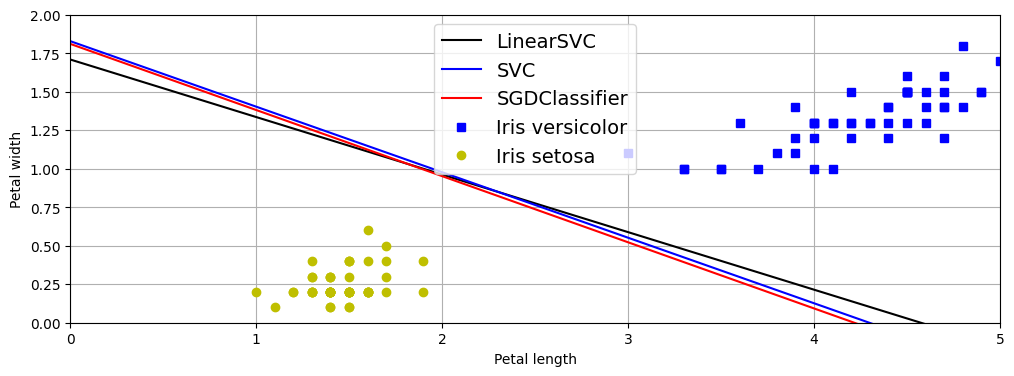

In [13]:
import matplotlib.pyplot as plt

def compute_decision_boundary(model):
  w=-model.coef_[0, 0]/ model.coef_[0,1]
  b=-model.intercept_[0]/ model.coef_[0,1]
  return scaler.inverse_transform([[-10, -10*w+b],[10, 10*w+b]])

lin_line=compute_decision_boundary(lin_clf)
svc_line=compute_decision_boundary(svc_clf)
sgd_line=compute_decision_boundary(sgd_clf)

plt.figure(figsize=(12, 4))
plt.plot(lin_line[:, 0], lin_line[:, 1], "k", label="LinearSVC")
plt.plot(svc_line[:, 0], svc_line[:, 1], "b", label="SVC")
plt.plot(sgd_line[:, 0], sgd_line[:, 1], "r", label="SGDClassifier")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper center", fontsize=14)
plt.axis([0, 5, 0, 2])
plt.grid()

In [14]:
from sklearn.datasets import load_wine

wine=load_wine(as_frame=True)

In [16]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(wine.data, wine.target, random_state=42)

In [18]:
X_train.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
100,12.08,2.08,1.70,17.5,97.0,2.23,2.17,0.26,1.40,3.30,1.27,2.96,710.0
122,12.42,4.43,2.73,26.5,102.0,2.20,2.13,0.43,1.71,2.08,0.92,3.12,365.0
154,12.58,1.29,2.10,20.0,103.0,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640.0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0


In [19]:
y_train.head()

,target
2,0
100,1
122,1
154,2
51,0


In [20]:
lin_clf=make_pipeline(StandardScaler(),
                      LinearSVC(dual=True, random_state=42))
lin_clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(dual=True, random_state=42))])

In [22]:
from sklearn.model_selection import cross_val_score
cross_val_score(lin_clf, X_train, y_train).mean()

np.float64(0.9774928774928775)

In [23]:
svm_clf=make_pipeline(StandardScaler(),
                      SVC(random_state=42, gamma='auto'))
cross_val_score(svm_clf, X_train, y_train).mean()

np.float64(0.9698005698005698)

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

param_distrib={
    "svc__gamma": loguniform(1e-3, 1e-1),
    "svc__C": uniform(1, 10)
}

rnd_search_cv=RandomizedSearchCV(svm_clf, param_distrib, n_iter=100, cv=5, random_state=42)

rnd_search_cv.fit(X_train, y_train)
rnd_search_cv.best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=np.float64(9.925589984899778),
                     gamma=np.float64(0.011986281799901188),
                     random_state=42))])

In [28]:
rnd_search_cv.best_params_

{'svc__C': np.float64(9.925589984899778),
 'svc__gamma': np.float64(0.011986281799901188)}

In [29]:
rnd_search_cv.best_score_

np.float64(0.9925925925925926)

In [30]:
rnd_search_cv.score(X_test, y_test)

0.9777777777777777

In [31]:
from sklearn.datasets import fetch_california_housing

housing=fetch_california_housing()

X=housing.data
y=housing.target

In [32]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.svm import LinearSVR

lin_svr=make_pipeline(StandardScaler(),
                      LinearSVR(dual=True, random_state=42))
lin_svr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr', LinearSVR(dual=True, random_state=42))])

In [34]:
lin_svr=make_pipeline(StandardScaler(),
                      LinearSVR(max_iter=5000, dual=True, random_state=42))
lin_svr.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr',
                 LinearSVR(dual=True, max_iter=5000, random_state=42))])

In [35]:
from sklearn.metrics import root_mean_squared_error

y_pred=lin_svr.predict(X_train)
rmse=root_mean_squared_error(y_train, y_pred)
rmse

0.979565447829459

In [36]:
svm_reg=make_pipeline(StandardScaler(),
                     SVR())
param_distrib={
    "svr__gamma": loguniform(1e-3, 1e-1),
    "svr__C": uniform(1,10)
}
rnd_search_cv=RandomizedSearchCV(svm_reg, param_distrib, n_iter=100, cv=3, random_state=42)
rnd_search_cv.fit(X_train[:2000], y_train[:2000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('standardscaler',
                                              StandardScaler()),
                                             ('svr', SVR())]),
                   n_iter=100,
                   param_distributions={'svr__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d7a9b0085f0>,
                                        'svr__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d7a9af3cf50>},
                   random_state=42)

In [37]:
rnd_search_cv.best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr',
                 SVR(C=np.float64(4.63629602379294),
                     gamma=np.float64(0.08781408196485979)))])

In [38]:
-cross_val_score(rnd_search_cv.best_estimator_, X_train, y_train,
                 scoring="neg_root_mean_squared_error").mean()

np.float64(0.5827048587724437)

In [39]:
y_pred=rnd_search_cv.best_estimator_.predict(X_test)
rmse=root_mean_squared_error(y_test, y_pred)
rmse

0.5854732265172238